2.	Implement spatial convolution on an image with different masks and test it with Gaussian, Sobel, and Laplacian masks. Show the Fourier transform of the results. Show the histograms.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [9]:
img=cv2.imread("E:\\BG\\bird.jpeg",0)


In [13]:

def gen_convolution(img,kernel):
    r,c=img.shape
    kr,kc=kernel.shape
    pad_r=kr//2
    pad_c=kc//2
    padded=np.pad(img,((pad_r,pad_r),(pad_c,pad_c)),mode='constant',constant_values=0)
    output=np.zeros((r,c),dtype=np.float32)
    for i in range(r):
        for j in range(c):
            region=padded[i:i+kr,j:j+kc]
            output[i,j]=np.sum(region*kernel)
    return output

In [15]:
gaussian=np.array([[1,2,1],[2,4,2],[1,2,1]])
g=gen_convolution(img,gaussian)
sobel=np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
s=gen_convolution(img,sobel)
laplacian=np.array([[0,1,0],[1,-4,1],[0,1,0]])
l=gen_convolution(img,laplacian)

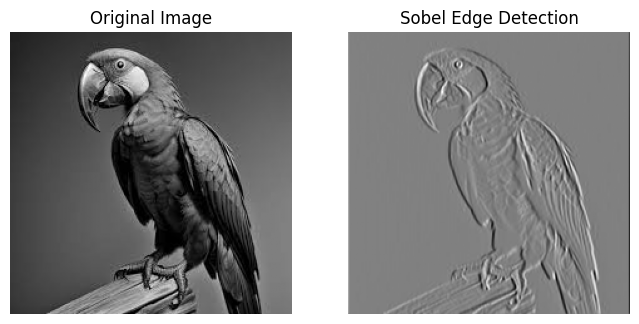

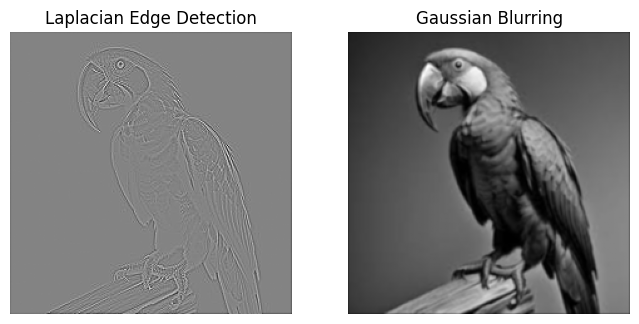

In [17]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(s,cmap='gray')
plt.title('Sobel Edge Detection')
plt.axis('off')
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(l,cmap='gray')
plt.title('Laplacian Edge Detection')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(g,cmap='gray')
plt.title('Gaussian Blurring')
plt.axis('off')
plt.show()


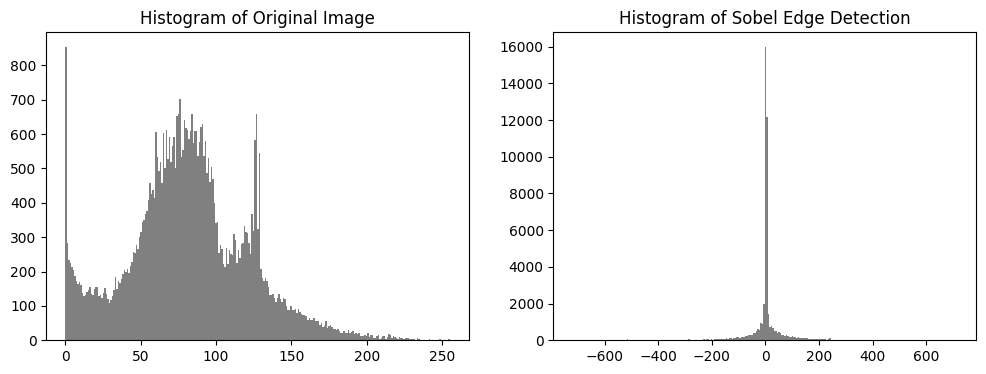

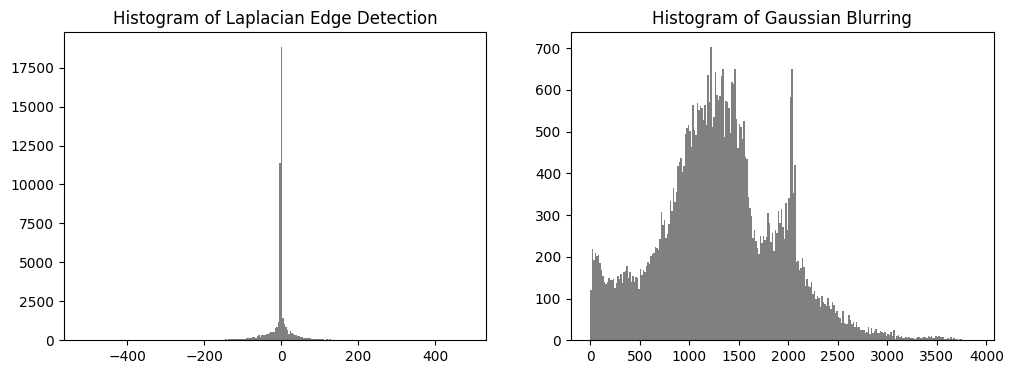

In [18]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(img.ravel(),bins=256,color='gray')
plt.title('Histogram of Original Image')

plt.subplot(1,2,2)
plt.hist(s.ravel(),bins=256,color='gray')
plt.title('Histogram of Sobel Edge Detection')

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(l.ravel(),bins=256,color='gray')
plt.title('Histogram of Laplacian Edge Detection')
plt.subplot(1,2,2)
plt.hist(g.ravel(),bins=256,color='gray')
plt.title('Histogram of Gaussian Blurring')
plt.show()